In [1]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root))

from src.incertidumbres import (
    graficar_imagen,
    crear_dataframe_incertidumbre,
    plot_incertidumbres,
    plot_combinado
)
from src.model_trainer import ModelTrainer
from src.image_preprocessor import ImagePreprocessor
import pickle
import pandas as pd
import tensorflow as tf

/Users/camcortes/Documents/birds-sounds/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model_name = "ResNet152V2" #"MobileNetV3Large" #"EfficientNetV2L" #"ResNet152V2" #"EfficientNetB7"

model_trainer = ModelTrainer(
    model_name=model_name,
    img_shape=(128, 256, 1),
    n_classes=667,
    dropout_rate=0.3,
    label_smoothing=0.1,
    fine_tune_layers=200
)

model = model_trainer.create_model()
model.summary()
model.load_weights(f"./models/weights_{model_name}.weights.h5")
tf.keras.backend.clear_session()

Model: "ResNet152V2_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 128, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ preprocess_input (Lambda)       │ (None, 128, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet152v2 (Functional)        │ (None, 2048)           │    58,331,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ top_dropout (Dropout)           │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (None, 667)            │     1,366,683 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,698,331 (227.73 MB)

 Trainable params: 32,846,491 (125.30 MB)

 Non-trainable params: 26,851,840 (102.43 MB)

/Users/camcortes/Documents/birds-sounds/.venv/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 368 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [3]:
with open(f'./models/label_encoder_{model_name}.pkl', 'rb') as f:
    label_encoder = pickle.load(f)

In [4]:
preprocessor = ImagePreprocessor(label_encoder=label_encoder)
data = preprocessor.load_data_from_directory("../src/data/images_test/images_spectograms")
data.head()

,label,image_path
0,Acropternis orthonyx,../src/data/images_test/images_spectograms/Acropternis orthonyx/121142_13.jpeg
1,Acropternis orthonyx,../src/data/images_test/images_spectograms/Acropternis orthonyx/511703_5.jpeg
2,Acropternis orthonyx,../src/data/images_test/images_spectograms/Acropternis orthonyx/461011_0.jpeg
3,Acropternis orthonyx,../src/data/images_test/images_spectograms/Acropternis orthonyx/621780_9.jpeg
4,Acropternis orthonyx,../src/data/images_test/images_spectograms/Acropternis orthonyx/428484_0.jpeg


In [5]:
sp_metrics = pd.read_csv("./models/incertidumbres_ResNet152V2.csv")

In [6]:
sp = data[data["label"] == "Lathrotriccus euleri"]
sp.sample(6)

,label,image_path
14663,Lathrotriccus euleri,../src/data/images_test/images_spectograms/Lathrotriccus euleri/586950_4.jpeg
14645,Lathrotriccus euleri,../src/data/images_test/images_spectograms/Lathrotriccus euleri/206677_15.jpeg
14651,Lathrotriccus euleri,../src/data/images_test/images_spectograms/Lathrotriccus euleri/414197_3.jpeg
14678,Lathrotriccus euleri,../src/data/images_test/images_spectograms/Lathrotriccus euleri/941658_3.jpeg
14673,Lathrotriccus euleri,../src/data/images_test/images_spectograms/Lathrotriccus euleri/586950_9.jpeg
14713,Lathrotriccus euleri,../src/data/images_test/images_spectograms/Lathrotriccus euleri/427525_5.jpeg


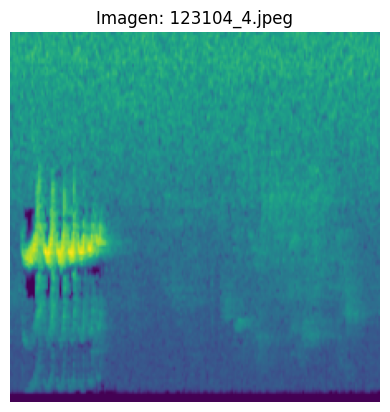

In [7]:
graficar_imagen(sp['image_path'].iloc[32])

# **Volatinia jacarina**

In [8]:
sp = data[data["label"] == "Volatinia jacarina"]
muestra = sp[sp['image_path'].str.contains('146774_0.jpeg')]
muestra

,label,image_path
31431,Volatinia jacarina,../src/data/images_test/images_spectograms/Volatinia jacarina/146774_0.jpeg


In [9]:
df_final, resultados = crear_dataframe_incertidumbre(data, muestra, model, preprocessor)
df_final.head()

Especies procesadas:   0%|          | 0/1 [00:00<?, ?it/s]


Especie 1 de 1, (Volatinia jacarina)


2025-11-30 15:49:56.660120: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Especies procesadas: 100%|██████████| 1/1 [07:24<00:00, 444.07s/it]


,especie,clase_real,clase_predicha,prediccion_mc,confianza_mc,true_positive,true_positivo_mc,entropia
0,Volatinia jacarina,651,651,651,0.82,1,1,1.05
1,Volatinia jacarina,651,651,651,0.93,1,1,1.05
2,Volatinia jacarina,651,651,651,0.86,1,1,1.05
3,Volatinia jacarina,651,651,651,0.94,1,1,1.05
4,Volatinia jacarina,651,651,651,0.72,1,1,1.05


In [10]:
Volatinia_jacarina = df_final['prediccion_mc'].\
    value_counts(normalize=True).reset_index().\
    sort_values(by='proportion', ascending=False).head(10)

In [11]:
Volatinia_jacarina

,prediccion_mc,proportion
0,651,1.00


/Users/camcortes/Documents/birds-sounds/src/incertidumbres.py:222: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


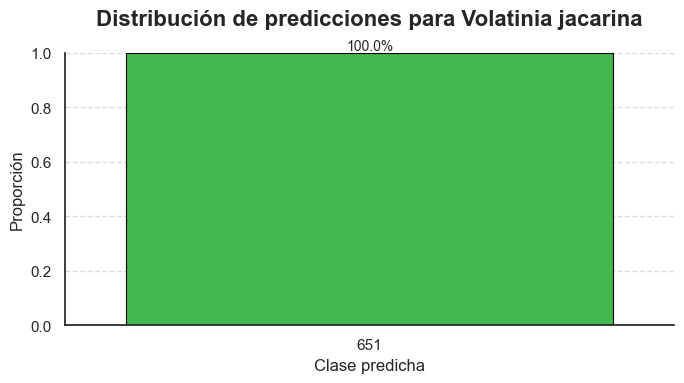

In [12]:
plot_incertidumbres(Volatinia_jacarina, 651, "Volatinia jacarina")

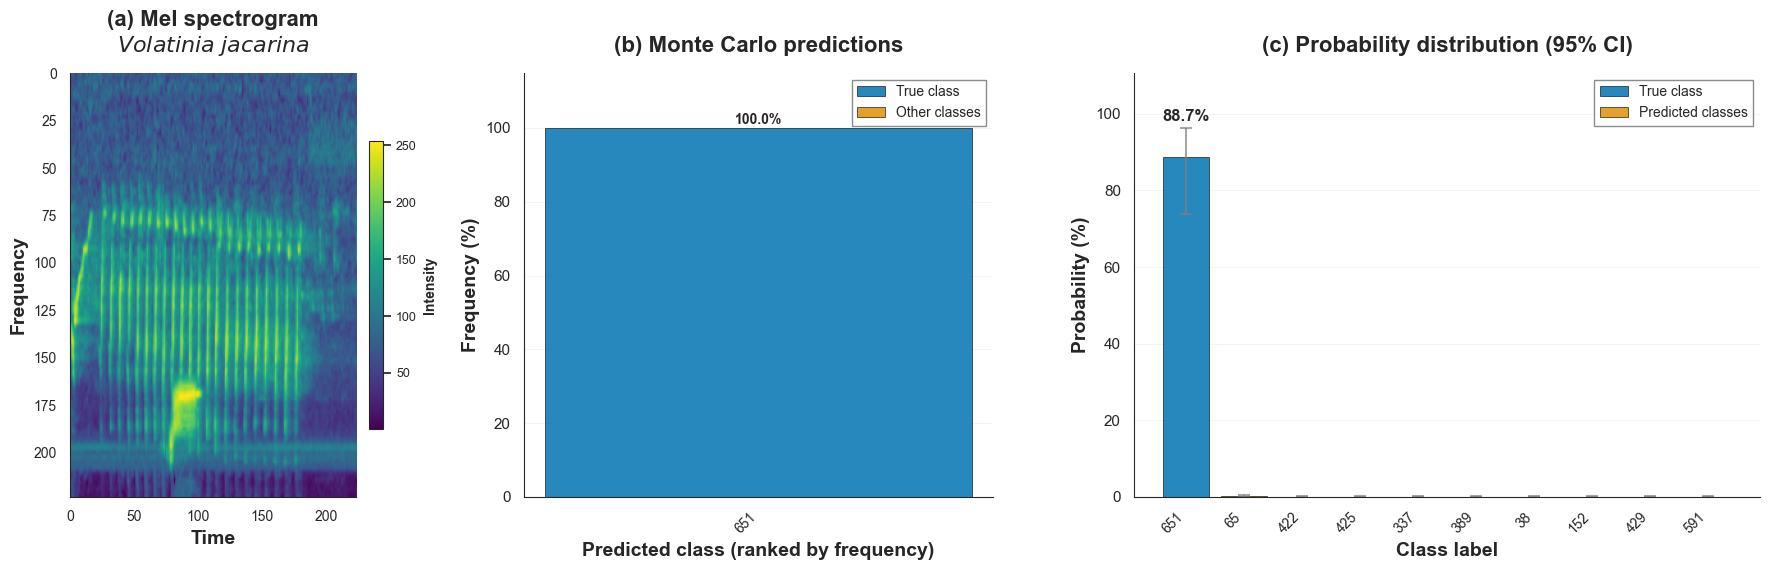

In [13]:
plot_combinado(
    ruta_imagen=sp['image_path'].iloc[1],
    especie_df=Volatinia_jacarina,
    label=651,
    titulo_especie="Volatinia jacarina",
    predicted_probabilities=resultados["Volatinia jacarina"]["predicted_probabilities"],
    etiqueta_real=resultados["Volatinia jacarina"]["clase_real"][0]
)

In [14]:
labels_frecuencia = [651, 65, 422, 425, 38, 389, 337, 429, 152, 591]

print("Especies con mayor probabilidad:\n")
for idx, label in enumerate(labels_frecuencia):
    print(f"{idx+1} - {label}: {label_encoder.inverse_transform([label])[0]}")

Especies con mayor probabilidad:

1 - 651: Volatinia jacarina
2 - 65: Cantorchilus leucotis
3 - 422: Pheugopedius fasciatoventris
4 - 425: Pheugopedius rutilus
5 - 38: Attila cinnamomeus
6 - 389: Myrmotherula menetriesii
7 - 337: Milvago chimachima
8 - 429: Phlegopsis nigromaculata
9 - 152: Daptrius ater
10 - 591: Tersina viridis


# **Legatus leucophaius**

In [15]:
sp = data[data["label"] == "Legatus leucophaius"]
muestra = sp[sp['image_path'].str.contains('275478_4.jpeg')]
muestra

,label,image_path
14744,Legatus leucophaius,../src/data/images_test/images_spectograms/Legatus leucophaius/275478_4.jpeg


In [16]:
df_final, resultados = crear_dataframe_incertidumbre(data, muestra, model, preprocessor)
df_final.head()

Especies procesadas:   0%|          | 0/1 [00:00<?, ?it/s]


Especie 1 de 1, (Legatus leucophaius)


2025-11-30 15:57:22.824224: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Especies procesadas: 100%|██████████| 1/1 [07:25<00:00, 445.80s/it]


,especie,clase_real,clase_predicha,prediccion_mc,confianza_mc,true_positive,true_positivo_mc,entropia
0,Legatus leucophaius,301,301,301,0.88,1,1,1.63
1,Legatus leucophaius,301,301,301,0.60,1,1,1.63
2,Legatus leucophaius,301,301,301,0.91,1,1,1.63
3,Legatus leucophaius,301,301,301,0.66,1,1,1.63
4,Legatus leucophaius,301,301,301,0.75,1,1,1.63


In [17]:
Legatus_leucophaius = df_final['prediccion_mc'].\
    value_counts(normalize=True).reset_index().\
    sort_values(by='proportion', ascending=False).head(10)

In [18]:
Legatus_leucophaius

,prediccion_mc,proportion
0,301,1.00


/Users/camcortes/Documents/birds-sounds/src/incertidumbres.py:222: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


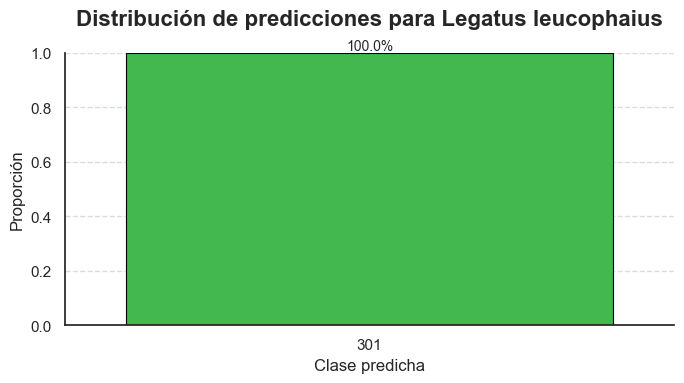

In [19]:
plot_incertidumbres(Legatus_leucophaius, 301, "Legatus leucophaius")

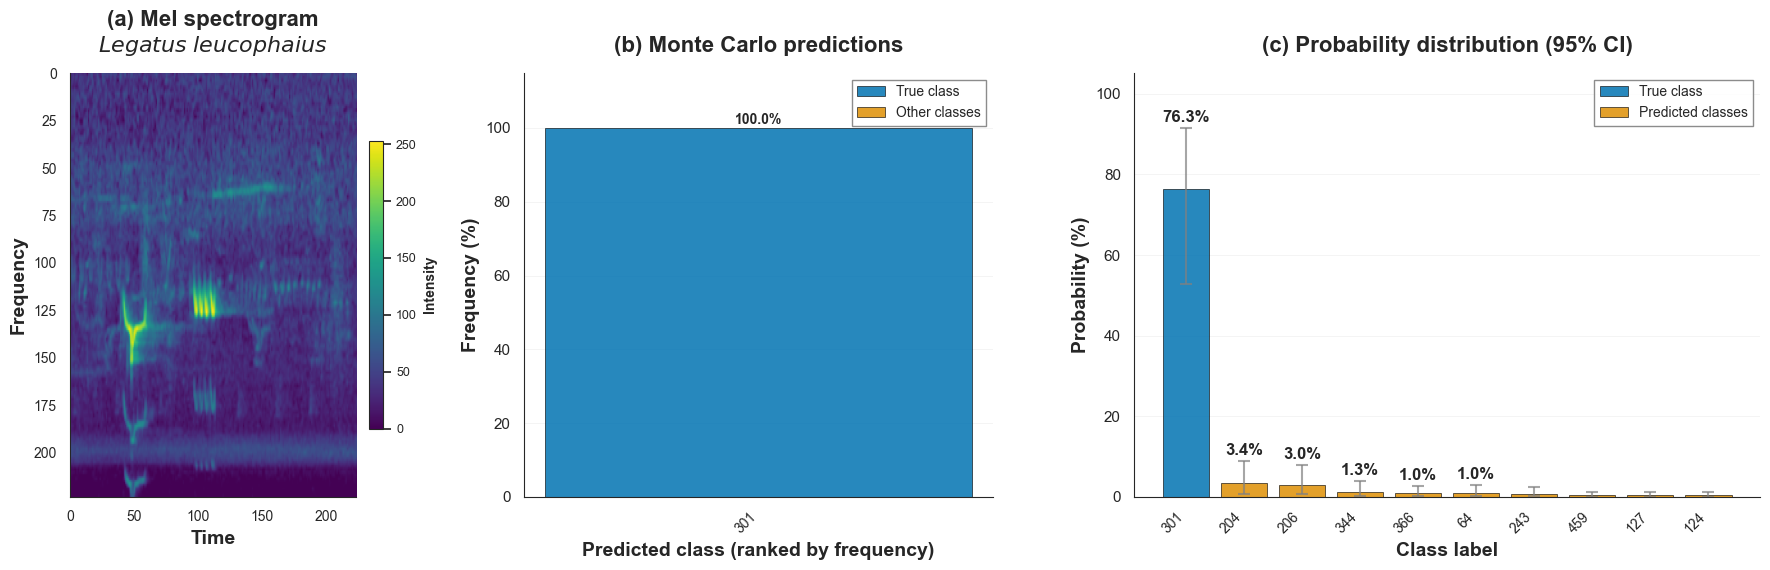

In [20]:
plot_combinado(
    ruta_imagen=sp['image_path'].iloc[1],
    especie_df=Legatus_leucophaius,
    label=301,
    titulo_especie="Legatus leucophaius",
    predicted_probabilities=resultados["Legatus leucophaius"]["predicted_probabilities"],
    etiqueta_real=resultados["Legatus leucophaius"]["clase_real"][0]
)

In [21]:
labels_frecuencia = [127, 128, 204, 214, 243, 301, 344, 608, 641, 654]

print("Especies con mayor probabilidad:\n")
for idx, label in enumerate(labels_frecuencia):
    print(f"{idx+1} - {label}: {label_encoder.inverse_transform([label])[0]}")

Especies con mayor probabilidad:

1 - 127: Contopus sordidulus
2 - 128: Contopus virens
3 - 204: Euphonia chlorotica
4 - 214: Euphonia xanthogaster
5 - 243: Grallaricula flavirostris
6 - 301: Legatus leucophaius
7 - 344: Myadestes ralloides
8 - 608: Thraupis episcopus
9 - 641: Vireo chivi
10 - 654: Xenops rutilans


# **Hylophilus thoracicus**

In [22]:
sp = data[data["label"] == "Hylophilus thoracicus"]
muestra = sp[sp['image_path'].str.contains('272368_8.jpeg')]
muestra

,label,image_path
13483,Hylophilus thoracicus,../src/data/images_test/images_spectograms/Hylophilus thoracicus/272368_8.jpeg


In [23]:
df_final, resultados = crear_dataframe_incertidumbre(data, muestra, model, preprocessor)
df_final.head()

Especies procesadas:   0%|          | 0/1 [00:00<?, ?it/s]


Especie 1 de 1, (Hylophilus thoracicus)


Especies procesadas: 100%|██████████| 1/1 [08:18<00:00, 498.29s/it]


,especie,clase_real,clase_predicha,prediccion_mc,confianza_mc,true_positive,true_positivo_mc,entropia
0,Hylophilus thoracicus,274,274,274,0.67,1,1,0.89
1,Hylophilus thoracicus,274,274,274,0.81,1,1,0.89
2,Hylophilus thoracicus,274,274,274,0.88,1,1,0.89
3,Hylophilus thoracicus,274,274,274,0.84,1,1,0.89
4,Hylophilus thoracicus,274,274,274,0.88,1,1,0.89


In [24]:
Hylophilus_thoracicus = df_final['prediccion_mc'].\
    value_counts(normalize=True).reset_index().\
    sort_values(by='proportion', ascending=False).head(10)

In [25]:
Hylophilus_thoracicus

,prediccion_mc,proportion
0,274,1.00


/Users/camcortes/Documents/birds-sounds/src/incertidumbres.py:222: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


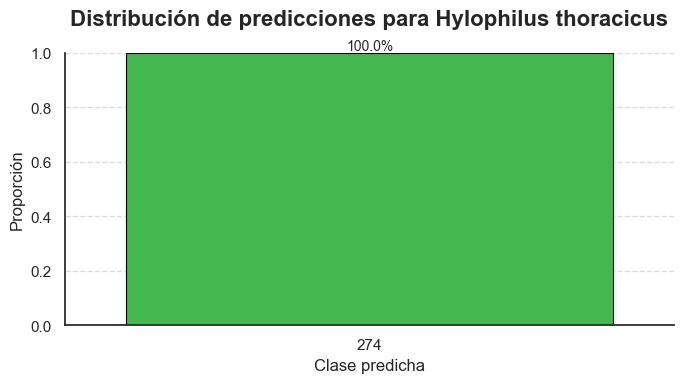

In [26]:
plot_incertidumbres(Hylophilus_thoracicus, 274, "Hylophilus thoracicus")

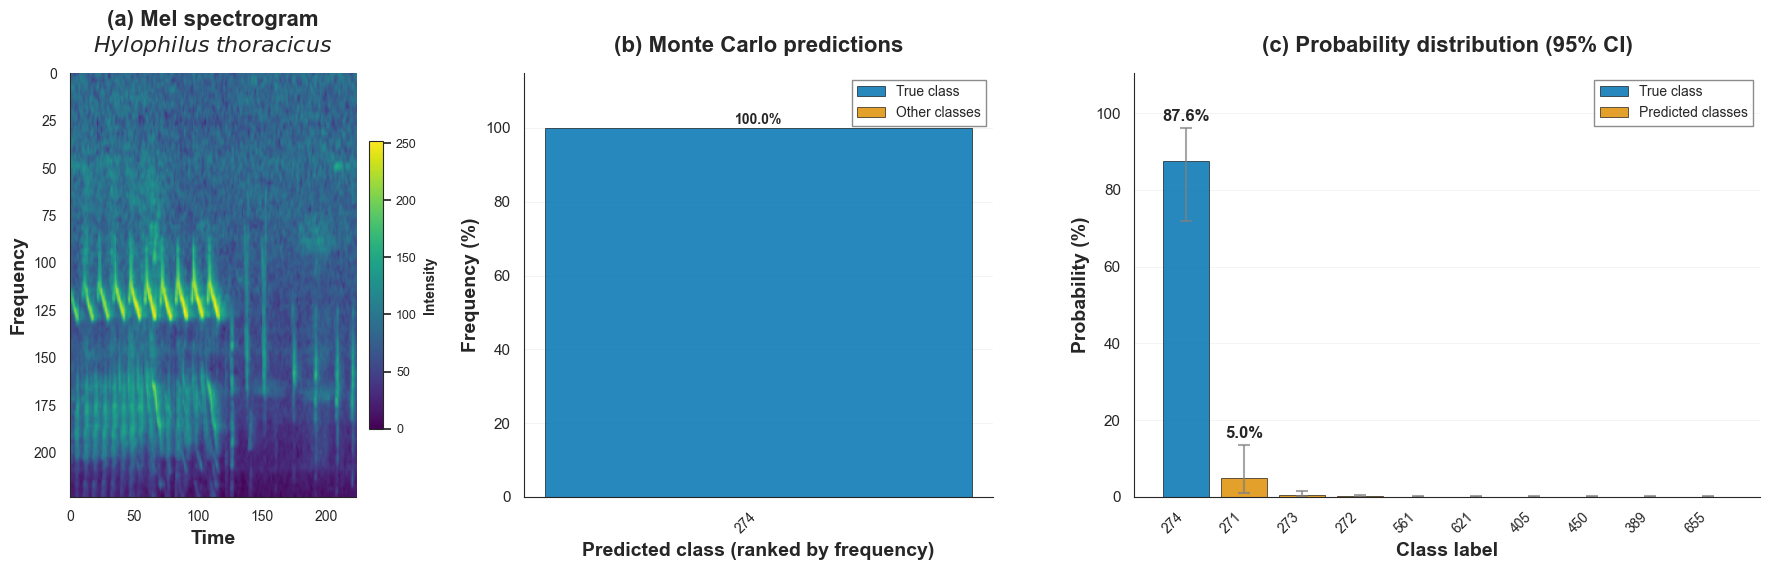

In [27]:
plot_combinado(
    ruta_imagen=sp['image_path'].iloc[0],
    especie_df=Hylophilus_thoracicus,
    label=274,
    titulo_especie="Hylophilus thoracicus",
    predicted_probabilities=resultados["Hylophilus thoracicus"]["predicted_probabilities"],
    etiqueta_real=resultados["Hylophilus thoracicus"]["clase_real"][0]
)

In [28]:
labels_frecuencia = [60, 186, 261, 274, 290, 301, 336, 452, 476, 494]

print("Especies con mayor probabilidad:\n")
for idx, label in enumerate(labels_frecuencia):
    print(f"{idx+1} - {label}: {label_encoder.inverse_transform([label])[0]}")

Especies con mayor probabilidad:

1 - 60: Campylorhamphus trochilirostris
2 - 186: Elaenia flavogaster
3 - 261: Henicorhina leucosticta
4 - 274: Hylophilus thoracicus
5 - 290: Inezia caudata
6 - 301: Legatus leucophaius
7 - 336: Microrhopias quixensis
8 - 452: Polioptila plumbea
9 - 476: Ramphastos tucanus
10 - 494: Saltator maximus


# **Mimus gilvus**

In [29]:
sp = data[data["label"] == "Mimus gilvus"]
muestra = sp[sp['image_path'].str.contains('40536_5.jpeg')]
muestra

,label,image_path
16615,Mimus gilvus,../src/data/images_test/images_spectograms/Mimus gilvus/40536_5.jpeg


In [30]:
df_final, resultados = crear_dataframe_incertidumbre(data, muestra, model, preprocessor)
df_final.head()

Especies procesadas:   0%|          | 0/1 [00:00<?, ?it/s]


Especie 1 de 1, (Mimus gilvus)


2025-11-30 16:13:28.585849: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Especies procesadas: 100%|██████████| 1/1 [07:46<00:00, 466.79s/it]


,especie,clase_real,clase_predicha,prediccion_mc,confianza_mc,true_positive,true_positivo_mc,entropia
0,Mimus gilvus,338,338,338,0.24,1,1,4.46
1,Mimus gilvus,338,338,338,0.40,1,1,4.46
2,Mimus gilvus,338,338,338,0.21,1,1,4.46
3,Mimus gilvus,338,338,338,0.15,1,1,4.46
4,Mimus gilvus,338,338,338,0.43,1,1,4.46


In [31]:
Mimus_gilvus = df_final['prediccion_mc'].\
    value_counts(normalize=True).reset_index().\
    sort_values(by='proportion', ascending=False).head(10)

In [32]:
Mimus_gilvus

,prediccion_mc,proportion
0,338,0.78
1,544,0.17
2,291,0.05
3,140,0.00
4,289,0.00


/Users/camcortes/Documents/birds-sounds/src/incertidumbres.py:222: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


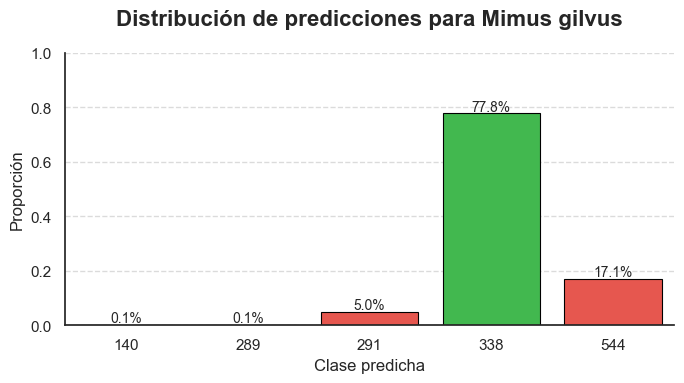

In [33]:
plot_incertidumbres(Mimus_gilvus, 338, "Mimus gilvus")

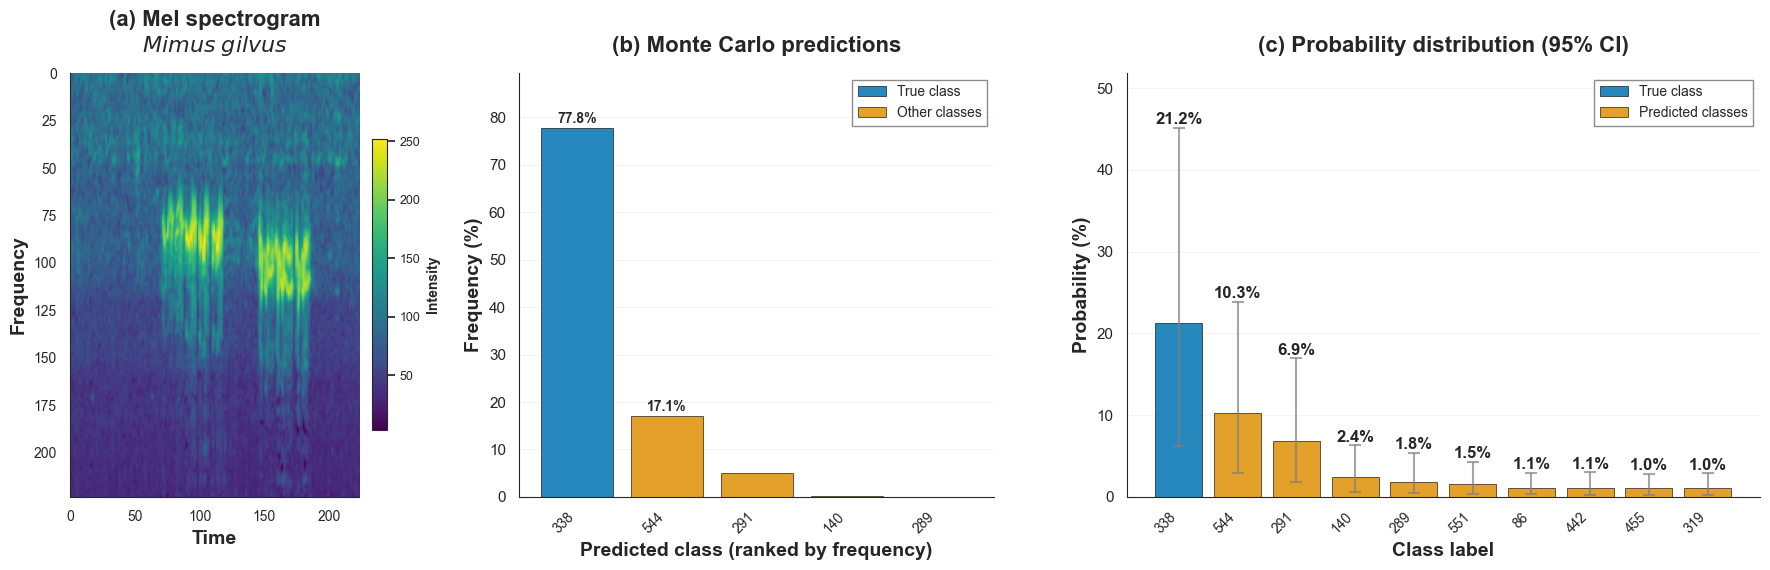

In [34]:
plot_combinado(
    ruta_imagen=sp['image_path'].iloc[20],
    especie_df=Mimus_gilvus,
    label=338,
    titulo_especie="Mimus gilvus",
    predicted_probabilities=resultados["Mimus gilvus"]["predicted_probabilities"],
    etiqueta_real=resultados["Mimus gilvus"]["clase_real"][0]
)

In [35]:
labels_frecuencia = [65, 316, 338, 494, 495, 544, 621, 636, 640, 666]

print("Especies con mayor probabilidad:\n")
for idx, label in enumerate(labels_frecuencia):
    print(f"{idx+1} - {label}: {label_encoder.inverse_transform([label])[0]}")

Especies con mayor probabilidad:

1 - 65: Cantorchilus leucotis
2 - 316: Lophotriccus pileatus
3 - 338: Mimus gilvus
4 - 494: Saltator maximus
5 - 495: Saltator striatipectus
6 - 544: Sporophila castaneiventris
7 - 621: Todirostrum cinereum
8 - 636: Tyrannus melancholicus
9 - 640: Vireo altiloquus
10 - 666: Zonotrichia leucophrys


# **Lathrotriccus euleri**

In [36]:
sp = data[data["label"] == "Lathrotriccus euleri"]
muestra = sp[sp['image_path'].str.contains('123104_4.jpeg')]
muestra

,label,image_path
14676,Lathrotriccus euleri,../src/data/images_test/images_spectograms/Lathrotriccus euleri/123104_4.jpeg


In [37]:
df_final, resultados = crear_dataframe_incertidumbre(data, muestra, model, preprocessor)
df_final.head()

Especies procesadas:   0%|          | 0/1 [00:00<?, ?it/s]


Especie 1 de 1, (Lathrotriccus euleri)


Especies procesadas: 100%|██████████| 1/1 [07:54<00:00, 474.83s/it]


,especie,clase_real,clase_predicha,prediccion_mc,confianza_mc,true_positive,true_positivo_mc,entropia
0,Lathrotriccus euleri,300,300,300,0.74,1,1,2.05
1,Lathrotriccus euleri,300,300,300,0.84,1,1,2.05
2,Lathrotriccus euleri,300,300,300,0.72,1,1,2.05
3,Lathrotriccus euleri,300,300,300,0.68,1,1,2.05
4,Lathrotriccus euleri,300,300,300,0.70,1,1,2.05


In [38]:
Lathrotriccus_euleri = df_final['prediccion_mc'].\
    value_counts(normalize=True).reset_index().\
    sort_values(by='proportion', ascending=False).head(10)

In [39]:
Lathrotriccus_euleri

,prediccion_mc,proportion
0,300,1.00


/Users/camcortes/Documents/birds-sounds/src/incertidumbres.py:222: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


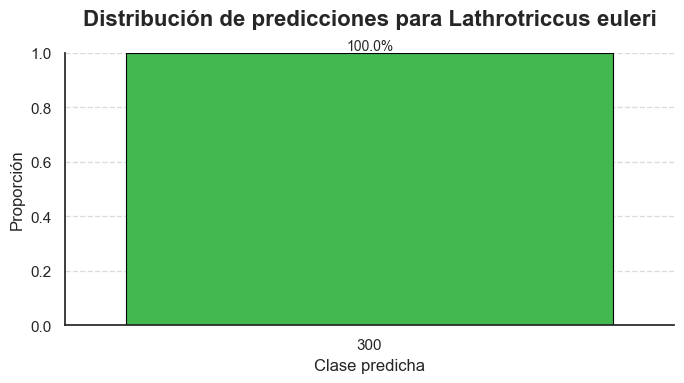

In [40]:
plot_incertidumbres(Lathrotriccus_euleri, 300, "Lathrotriccus euleri")

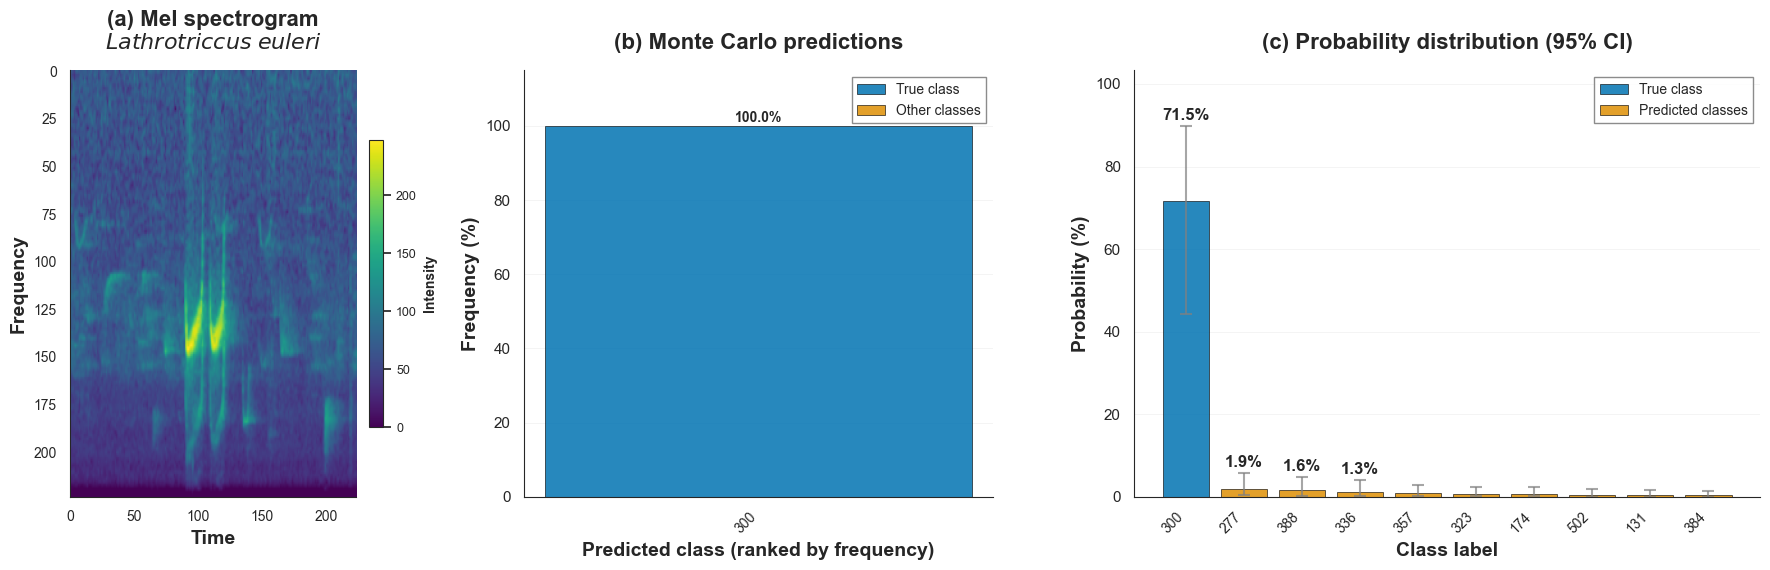

In [41]:
plot_combinado(
    ruta_imagen=sp['image_path'].iloc[20],
    especie_df=Lathrotriccus_euleri,
    label=300,
    titulo_especie="Lathrotriccus euleri",
    predicted_probabilities=resultados["Lathrotriccus euleri"]["predicted_probabilities"],
    etiqueta_real=resultados["Lathrotriccus euleri"]["clase_real"][0]
)

In [42]:
labels_frecuencia = [300, 277, 388, 336, 357, 323, 174, 502, 131, 281]

print("Especies con mayor probabilidad:\n")
for idx, label in enumerate(labels_frecuencia):
    print(f"{idx+1} - {label}: {label_encoder.inverse_transform([label])[0]}")

Especies con mayor probabilidad:

1 - 300: Lathrotriccus euleri
2 - 277: Hylophylax punctulatus
3 - 388: Myrmotherula longipennis
4 - 336: Microrhopias quixensis
5 - 357: Myiopagis viridicata
6 - 323: Manacus manacus
7 - 174: Drymophila devillei
8 - 502: Sciaphylax castanea
9 - 131: Corythopis torquatus
10 - 281: Hypocnemoides melanopogon


# **Riparia riparia**

In [43]:
sp = data[data["label"] == "Riparia riparia"]
muestra = sp[sp['image_path'].str.contains('123938_17.jpeg')]
muestra

,label,image_path
23652,Riparia riparia,../src/data/images_test/images_spectograms/Riparia riparia/123938_17.jpeg


In [44]:
sp = data[data["label"] == "Riparia riparia"]
muestra = sp[sp['image_path'].str.contains('448123_18.jpeg')]
muestra

,label,image_path
23655,Riparia riparia,../src/data/images_test/images_spectograms/Riparia riparia/448123_18.jpeg


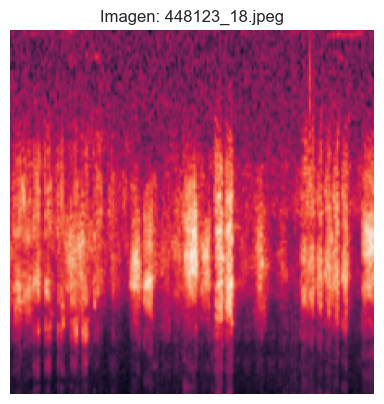

In [45]:
graficar_imagen(sp['image_path'].iloc[3])

In [46]:
df_final, resultados = crear_dataframe_incertidumbre(data, muestra, model, preprocessor)
df_final.head()

Especies procesadas:   0%|          | 0/1 [00:00<?, ?it/s]


Especie 1 de 1, (Riparia riparia)


Especies procesadas: 100%|██████████| 1/1 [08:47<00:00, 527.73s/it]


,especie,clase_real,clase_predicha,prediccion_mc,confianza_mc,true_positive,true_positivo_mc,entropia
0,Riparia riparia,487,487,487,0.35,1,1,1.82
1,Riparia riparia,487,487,487,0.52,1,1,1.82
2,Riparia riparia,487,487,487,0.77,1,1,1.82
3,Riparia riparia,487,487,487,0.79,1,1,1.82
4,Riparia riparia,487,487,487,0.78,1,1,1.82


In [47]:
Riparia_riparia = df_final['prediccion_mc'].\
    value_counts(normalize=True).reset_index().\
    sort_values(by='proportion', ascending=False).head(10)

In [48]:
Riparia_riparia

,prediccion_mc,proportion
0,487,0.99
1,416,0.01


/Users/camcortes/Documents/birds-sounds/src/incertidumbres.py:222: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


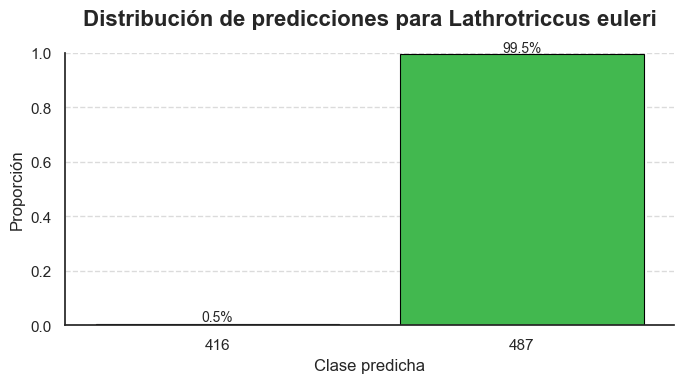

In [49]:
plot_incertidumbres(Riparia_riparia, 487, "Lathrotriccus euleri")

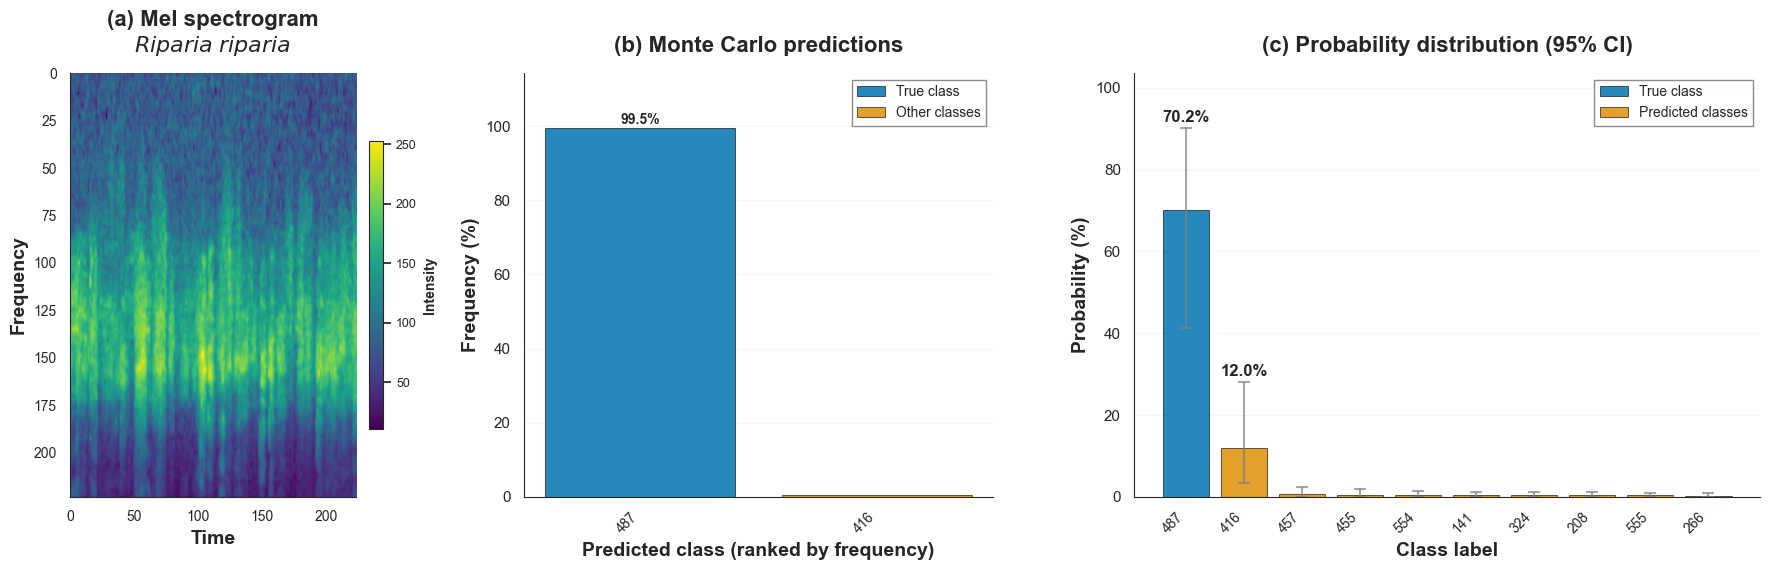

In [50]:
plot_combinado(
    ruta_imagen=sp['image_path'].iloc[20],
    especie_df=Riparia_riparia,
    label=487,
    titulo_especie="Riparia riparia",
    predicted_probabilities=resultados["Riparia riparia"]["predicted_probabilities"],
    etiqueta_real=resultados["Riparia riparia"]["clase_real"][0]
)

In [51]:
labels_frecuencia = [487, 416, 457, 455, 554, 141, 324, 208, 555, 266]

print("Especies con mayor probabilidad:\n")
for idx, label in enumerate(labels_frecuencia):
    print(f"{idx+1} - {label}: {label_encoder.inverse_transform([label])[0]}")

Especies con mayor probabilidad:

1 - 487: Riparia riparia
2 - 416: Petrochelidon pyrrhonota
3 - 457: Progne tapera
4 - 455: Progne chalybea
5 - 554: Stelgidopteryx ruficollis
6 - 141: Cyanocorax yncas
7 - 324: Mazaria propinqua
8 - 208: Euphonia laniirostris
9 - 555: Stelgidopteryx serripennis
10 - 266: Hirundo rustica


# **Incertidumbres**

In [53]:
df = pd.read_csv("../src/data/incertidumbres_ResNet152V2.csv")
print(df.shape)

(667, 7)


In [54]:
import numpy as np
import re
import ast

def string_to_numpy_array(string_array):
    """
    Convierte un string que representa un array numpy a un array real
    Por ejemplo: "[np.int64(218), np.int64(321), ...]" → [218, 321, ...]
    """
    if not isinstance(string_array, str):
        return string_array

    try:
        # Reemplazar np.int64(...) con solo el número
        string_clean = re.sub(r'np\.int64\((\d+)\)', r'\1', string_array)

        # Reemplazar np.float32(...) con solo el número
        string_clean = re.sub(r'np\.float32\(([\d.e-]+)\)', r'\1', string_clean)

        # Reemplazar np.float64(...) con solo el número
        string_clean = re.sub(r'np\.float64\(([\d.e-]+)\)', r'\1', string_clean)

        # Evaluar como lista de Python
        lista = ast.literal_eval(string_clean)

        # Convertir a array numpy
        return np.array(lista)

    except Exception as e:
        print(f"Error al convertir: {e}")
        print(f"String original (primeros 100 chars): {string_array[:100]}")
        return None

# Aplicar la conversión a las columnas del DataFrame
print("Convirtiendo strings a arrays...")
df['predicciones_mc'] = df['predicciones_mc'].apply(string_to_numpy_array)
df['confianzas_mc'] = df['confianzas_mc'].apply(string_to_numpy_array)

# Verificar que la conversión funcionó
print("\nDespués de la conversión:")
print(f"Tipo de predicciones_mc[0]: {type(df['predicciones_mc'].iloc[0])}")
print(f"Shape si es array: {df['predicciones_mc'].iloc[0].shape if hasattr(df['predicciones_mc'].iloc[0], 'shape') else 'No es array'}")
print(f"Primeros 5 elementos: {df['predicciones_mc'].iloc[0][:5] if hasattr(df['predicciones_mc'].iloc[0], '__getitem__') else 'No indexable'}")

# Ahora sí podemos expandir
def expandir_arrays_a_filas_v2(df):
    """
    Expande arrays en múltiples filas
    """
    filas_expandidas = []

    for idx, fila in df.iterrows():
        predicciones = fila['predicciones_mc']
        confianzas = fila['confianzas_mc']

        if predicciones is None or confianzas is None:
            print(f"Saltando fila {idx} - conversión fallida")
            continue

        if isinstance(predicciones, np.ndarray) and isinstance(confianzas, np.ndarray):
            # Asegurar que tengan el mismo tamaño
            min_length = min(len(predicciones), len(confianzas))

            # Crear una fila por cada elemento
            for i in range(min_length):
                nueva_fila = fila.copy()
                nueva_fila['prediccion_mc_individual'] = int(predicciones[i])
                nueva_fila['confianza_mc_individual'] = float(confianzas[i])
                nueva_fila['iteracion_mc'] = i
                filas_expandidas.append(nueva_fila)

    # Crear DataFrame expandido
    df_expandido = pd.DataFrame(filas_expandidas)

    # Reorganizar columnas
    columnas_base = [col for col in df_expandido.columns
                     if col not in ['predicciones_mc', 'confianzas_mc',
                                   'prediccion_mc_individual', 'confianza_mc_individual',
                                   'iteracion_mc']]
    columnas_nuevas = columnas_base + ['iteracion_mc', 'prediccion_mc_individual', 'confianza_mc_individual']

    return df_expandido[columnas_nuevas]

# Expandir el DataFrame
df_expandido = expandir_arrays_a_filas_v2(df)

Convirtiendo strings a arrays...

Después de la conversión:
Tipo de predicciones_mc[0]: <class 'numpy.ndarray'>
Shape si es array: (52,)
Primeros 5 elementos: [76 76 76 76 76]


In [55]:
import ast
import re

def extraer_numero_clase(valor):
    """
    Extrae el número de strings como '[np.int64(44)]'
    """
    if isinstance(valor, int):
        return valor

    # Convertir a string si no lo es
    valor_str = str(valor)

    # Reemplazar np.int64(...) con solo el número
    valor_limpio = re.sub(r'np\.int64\((\d+)\)', r'\1', valor_str)

    # Evaluar y obtener el primer elemento
    try:
        lista = ast.literal_eval(valor_limpio)
        return int(lista[0]) if isinstance(lista, list) else int(lista)
    except:
        # Si falla, intentar extraer directamente con regex
        numeros = re.findall(r'\d+', valor_str)
        return int(numeros[0]) if numeros else None

# Aplicar la función
df_expandido['clase_real'] = df_expandido['clase_real'].apply(extraer_numero_clase)
df_expandido['clase_predicha_inferencia'] = df_expandido['clase_predicha_inferencia'].apply(extraer_numero_clase)

In [56]:
df_expandido = df_expandido.rename(columns={'Unnamed: 0': 'especie'})
print(df_expandido.shape)
df_expandido.head()

(32279, 8)


,especie,clase_real,clase_predicha_inferencia,proporcion_coincidencia,porcentaje_coincidencia,iteracion_mc,prediccion_mc_individual,confianza_mc_individual
0,Celeus flavus,76,76,1.00,100.00,0,76,0.92
0,Celeus flavus,76,76,1.00,100.00,1,76,0.95
0,Celeus flavus,76,76,1.00,100.00,2,76,0.98
0,Celeus flavus,76,76,1.00,100.00,3,76,0.95
0,Celeus flavus,76,76,1.00,100.00,4,76,0.35


In [57]:
accuracy_por_especie = (
    df_expandido
    .assign(acierto = lambda df: df['clase_real'] == df['prediccion_mc_individual'])
    .groupby('especie')['acierto']
    .mean()
    .reset_index(name='accuracy')
)

In [58]:
# Mostrar estadísticas generales
print("=== ESTADÍSTICAS GENERALES ===")
print(f"Accuracy promedio: {accuracy_por_especie['accuracy'].mean():.4f}")
print(f"Accuracy mediano: {accuracy_por_especie['accuracy'].median():.4f}")
print(f"Desviación estándar: {accuracy_por_especie['accuracy'].std():.4f}")
print(f"Número de especies: {len(accuracy_por_especie)}")

=== ESTADÍSTICAS GENERALES ===
Accuracy promedio: 0.8481
Accuracy mediano: 0.8571
Desviación estándar: 0.0853
Número de especies: 667


In [59]:
def accuracy_calculo(df):
    accuracy_results = []

    for i in range(len(df)):
        if df['clase_real'].iloc[i] == df['prediccion_mc_individual'].iloc[i]:
            accuracy_results.append(1)
        else:
            accuracy_results.append(0)

    return sum(accuracy_results)/len(accuracy_results)

print(f"El Accuracy de las incertidumbres de Monte Carlo Dropout es: {accuracy_calculo(df_expandido)}")

El Accuracy de las incertidumbres de Monte Carlo Dropout es: 0.854518417547012


In [60]:
# Top 20 especies con MAYOR accuracy
print("\n=== TOP 20 ESPECIES CON MAYOR ACCURACY ===")
top_especies = accuracy_por_especie.head(20)
for idx, row in top_especies.iterrows():
    print(f"{row['especie']:40s} - Accuracy: {row['accuracy']:.3f}")

# Top 20 especies con MENOR accuracy
print("\n=== TOP 20 ESPECIES CON MENOR ACCURACY ===")
bottom_especies = accuracy_por_especie.tail(20)
for idx, row in bottom_especies.iterrows():
    print(f"{row['especie']:40s} - Accuracy: {row['accuracy']:.3f}")

# Análisis por rangos de accuracy
print("\n=== DISTRIBUCIÓN POR RANGOS DE ACCURACY ===")
rangos = pd.cut(accuracy_por_especie['accuracy'],
                bins=[0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
                labels=['0-10%', '10-30%', '30-50%', '50-70%', '70-90%', '90-100%'])
distribucion = rangos.value_counts().sort_index()
for rango, count in distribucion.items():
    print(f"{rango}: {count} especies ({count/len(accuracy_por_especie)*100:.1f}%)")

# Especies con accuracy perfecto (100%)
especies_perfectas = accuracy_por_especie[accuracy_por_especie['accuracy'] == 1.0]
print(f"\n=== ESPECIES CON ACCURACY PERFECTO (100%) ===")
print(f"Total: {len(especies_perfectas)} especies")
if len(especies_perfectas) > 0:
    for idx, row in especies_perfectas.iterrows():
        print(f"- {row['especie']}")

# Especies con accuracy cero
especies_cero = accuracy_por_especie[accuracy_por_especie['accuracy'] == 0.0]
print(f"\n=== ESPECIES CON ACCURACY CERO ===")
print(f"Total: {len(especies_cero)} especies")
if len(especies_cero) > 0:
    for idx, row in especies_cero.head(10).iterrows():  # Mostrar solo las primeras 10
        print(f"- {row['especie']}")
    if len(especies_cero) > 10:
        print(f"... y {len(especies_cero) - 10} especies más")


=== TOP 20 ESPECIES CON MAYOR ACCURACY ===
Acropternis orthonyx                     - Accuracy: 0.920
Amblycercus holosericeus                 - Accuracy: 0.815
Ammodramus aurifrons                     - Accuracy: 0.862
Ammodramus humeralis                     - Accuracy: 0.784
Ammodramus savannarum                    - Accuracy: 0.880
Anabacerthia striaticollis               - Accuracy: 0.778
Anabacerthia variegaticeps               - Accuracy: 0.886
Anairetes parulus                        - Accuracy: 0.944
Andigena nigrirostris                    - Accuracy: 0.841
Anisognathus igniventris                 - Accuracy: 0.882
Anisognathus lacrymosus                  - Accuracy: 0.808
Anisognathus somptuosus                  - Accuracy: 0.846
Anthus lutescens                         - Accuracy: 0.750
Anthus rubescens                         - Accuracy: 0.778
Ara ararauna                             - Accuracy: 0.907
Arremon assimilis                        - Accuracy: 0.893
Arremon atri

In [61]:
accuracy_por_especie.sort_values(by='accuracy', ascending=False).head(10)

,especie,accuracy
580,Tachyphonus delatrii,1.00
233,Grallaria kaestneri,1.00
497,Schiffornis aenea,1.00
459,Psarocolius bifasciatus,1.00
16,Arremon atricapillus,1.00
583,Tangara chilensis,1.00
375,Myrmelastes schistaceus,1.00
365,Myiotheretes fumigatus,1.00
167,Diglossa gloriosissima,1.00
206,Euphonia concinna,1.00


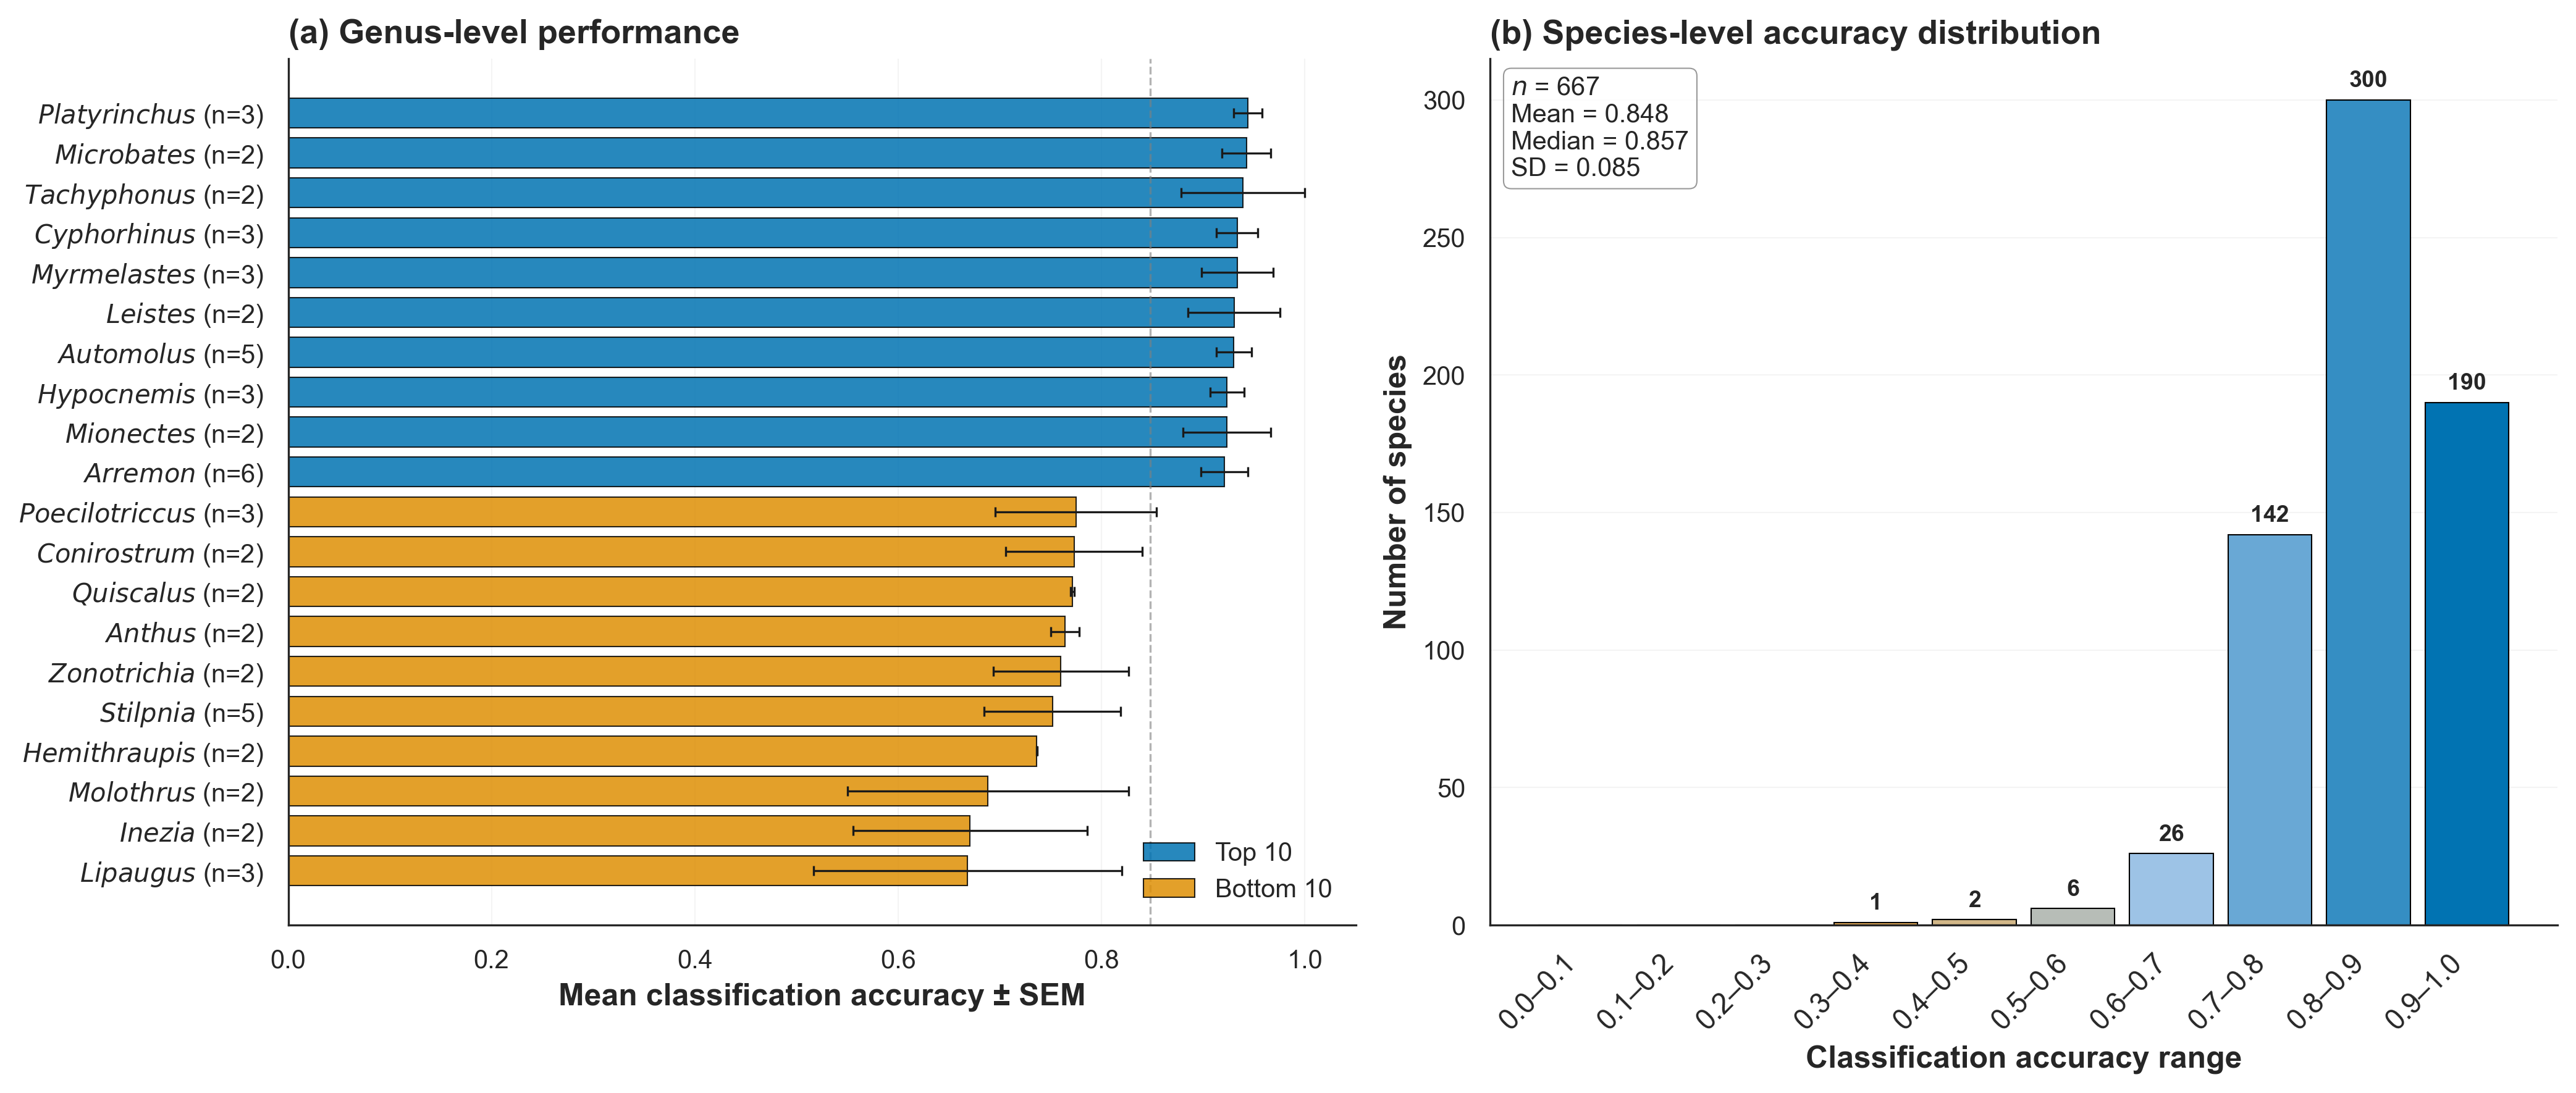


=== STATISTICS FOR MANUSCRIPT ===
Taxonomic coverage: 302 genera, 667 species
Mean accuracy: 0.848 ± 0.085
Best genus: Platyrinchus (0.944 ± 0.014)
Worst genus: Lipaugus (0.668 ± 0.151)


In [62]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Configuración para artículo científico (estilo Nature/Science)
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 10,
    'axes.linewidth': 0.8,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'legend.fontsize': 10,
    'legend.frameon': False,
    'figure.dpi': 300,
    'savefig.dpi': 300
})

# Extraer género de cada especie
accuracy_por_especie['genero'] = accuracy_por_especie['especie'].str.split().str[0]

# Calcular estadísticas por género
accuracy_por_genero = (
    accuracy_por_especie
    .groupby('genero')
    .agg({'accuracy': ['mean', 'std', 'count']})
)

accuracy_por_genero.columns = ['accuracy_mean', 'accuracy_std', 'n_species']
accuracy_por_genero = accuracy_por_genero.reset_index()

# Calcular error estándar de la media (SEM)
accuracy_por_genero['sem'] = accuracy_por_genero['accuracy_std'] / np.sqrt(accuracy_por_genero['n_species'])
accuracy_por_genero['sem'] = accuracy_por_genero['sem'].fillna(0)

# Filtrar géneros con ≥2 especies
accuracy_por_genero_filtrado = accuracy_por_genero[accuracy_por_genero['n_species'] >= 2].copy()
accuracy_por_genero_filtrado = accuracy_por_genero_filtrado.sort_values('accuracy_mean', ascending=False)

# ===== FIGURA: Panel con dos subplots =====
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), facecolor='white')

# Colores colorblind-friendly
color_high = '#0173B2'  # Azul
color_low = '#DE8F05'   # Naranja

# --- PANEL A: Top 10 vs Bottom 10 géneros ---
top_10 = accuracy_por_genero_filtrado.head(10)
bottom_10 = accuracy_por_genero_filtrado.tail(10)
combined = pd.concat([top_10, bottom_10]).sort_values('accuracy_mean', ascending=True)

y_pos = np.arange(len(combined))
colors = [color_high if genus in top_10['genero'].values else color_low 
          for genus in combined['genero']]

ax1.barh(y_pos, combined['accuracy_mean'], 
         xerr=combined['sem'],
         color=colors, alpha=0.85,
         edgecolor='black', linewidth=0.5,
         height=0.75,
         error_kw={'elinewidth': 0.8, 'capsize': 2, 'capthick': 0.8})

# Etiquetas en itálica
labels = [f"$\it{{{row['genero']}}}$ (n={int(row['n_species'])})" 
          for _, row in combined.iterrows()]

ax1.set_yticks(y_pos)
ax1.set_yticklabels(labels, fontsize=10)
ax1.set_xlabel('Mean classification accuracy ± SEM', fontsize=12, fontweight='bold')
ax1.set_title('(a) Genus-level performance', fontsize=13, fontweight='bold', loc='left')

# Línea de referencia
mean_overall = accuracy_por_especie['accuracy'].mean()
ax1.axvline(x=mean_overall, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

ax1.grid(axis='x', alpha=0.2, linewidth=0.5)
ax1.set_axisbelow(True)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Leyenda
legend_elements = [
    plt.Rectangle((0,0),1,1, fc=color_high, alpha=0.85, ec='black', lw=0.5, label='Top 10'),
    plt.Rectangle((0,0),1,1, fc=color_low, alpha=0.85, ec='black', lw=0.5, label='Bottom 10')
]
ax1.legend(handles=legend_elements, loc='lower right', frameon=False, fontsize=10)

# --- PANEL B: Distribución de accuracy por especies ---
bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
rangos_accuracy = pd.cut(accuracy_por_especie['accuracy'], bins=bins)
conteo_rangos = rangos_accuracy.value_counts().sort_index()

bin_labels = ['0.0–0.1', '0.1–0.2', '0.2–0.3', '0.3–0.4', '0.4–0.5',
              '0.5–0.6', '0.6–0.7', '0.7–0.8', '0.8–0.9', '0.9–1.0']

# Crear gradiente de colores científico (de naranja a azul)
# Bajo rendimiento (naranja) -> Alto rendimiento (azul)
import matplotlib.colors as mcolors
n_bars = len(conteo_rangos)
cmap = mcolors.LinearSegmentedColormap.from_list(
    'custom', ['#DE8F05', '#ECB159', '#9DC3E6', '#0173B2'], N=n_bars
)
colors_gradient = [cmap(i/max(1, n_bars-1)) for i in range(n_bars)]

ax2.bar(range(len(conteo_rangos)), conteo_rangos.values,
        color=colors_gradient,
        edgecolor='black', linewidth=0.5,
        width=0.85)

ax2.set_xticks(range(len(conteo_rangos)))
ax2.set_xticklabels(bin_labels, rotation=45, ha='right', fontsize=11)
ax2.set_xlabel('Classification accuracy range', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of species', fontsize=12, fontweight='bold')
ax2.set_title('(b) Species-level accuracy distribution', fontsize=13, fontweight='bold', loc='left')

ax2.grid(axis='y', alpha=0.2, linewidth=0.5)
ax2.set_axisbelow(True)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Valores sobre barras
for i, (bar, value) in enumerate(zip(ax2.patches, conteo_rangos.values)):
    if value > 0:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(conteo_rangos.values) * 0.01,
                str(int(value)), ha='center', va='bottom', fontsize=9, fontweight='bold')

# Estadísticas en recuadro
textstr = f'$n$ = {len(accuracy_por_especie)}\n'
textstr += f'Mean = {accuracy_por_especie["accuracy"].mean():.3f}\n'
textstr += f'Median = {accuracy_por_especie["accuracy"].median():.3f}\n'
textstr += f'SD = {accuracy_por_especie["accuracy"].std():.3f}'

props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray', linewidth=0.5)
ax2.text(0.02, 0.98, textstr, transform=ax2.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.savefig('../fig/monte_carlo_uncertainty_analysis.png', dpi=300, bbox_inches='tight')
plt.savefig('../fig/monte_carlo_uncertainty_analysis.pdf', bbox_inches='tight')
plt.show()

# Estadísticas para el manuscrito
print("\n=== STATISTICS FOR MANUSCRIPT ===")
print(f"Taxonomic coverage: {len(accuracy_por_genero)} genera, {len(accuracy_por_especie)} species")
print(f"Mean accuracy: {accuracy_por_especie['accuracy'].mean():.3f} ± {accuracy_por_especie['accuracy'].std():.3f}")
print(f"Best genus: {accuracy_por_genero_filtrado.iloc[0]['genero']} ({accuracy_por_genero_filtrado.iloc[0]['accuracy_mean']:.3f} ± {accuracy_por_genero_filtrado.iloc[0]['sem']:.3f})")
print(f"Worst genus: {accuracy_por_genero_filtrado.iloc[-1]['genero']} ({accuracy_por_genero_filtrado.iloc[-1]['accuracy_mean']:.3f} ± {accuracy_por_genero_filtrado.iloc[-1]['sem']:.3f})")

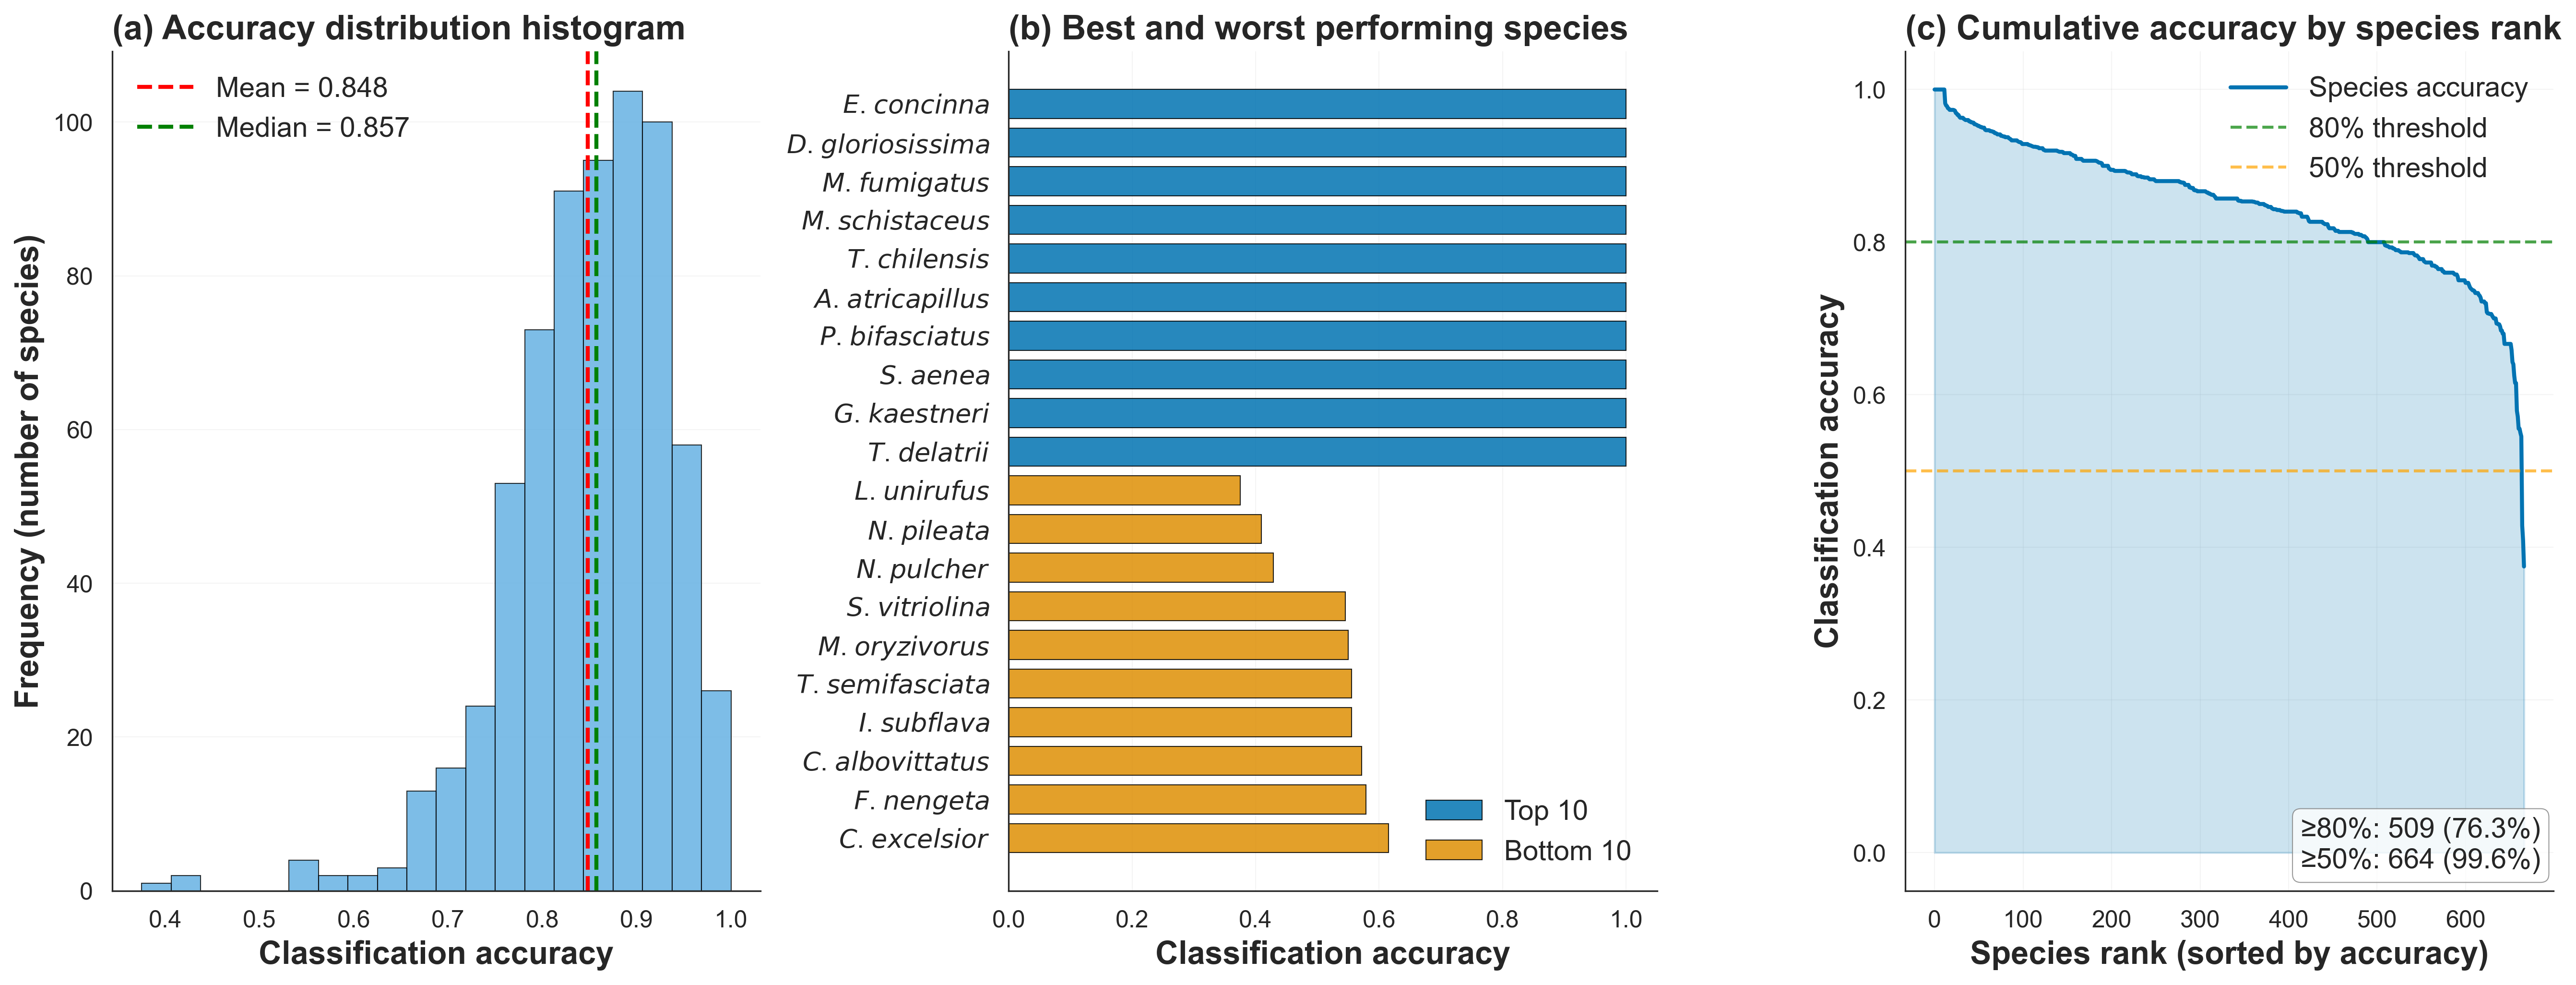


=== SPECIES PERFORMANCE STATISTICS ===
Total species: 667
Mean accuracy: 0.848 ± 0.085
Median accuracy: 0.857
Range: [0.375, 1.000]

Species with accuracy ≥0.8: 509 (76.3%)
Species with accuracy ≥0.5: 664 (99.6%)
Species with accuracy <0.5: 3 (0.4%)


In [63]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Configuración para artículo científico
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 12,
    'axes.linewidth': 0.8,
    'axes.labelsize': 14,
    'axes.titlesize': 15,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'legend.frameon': False,
    'figure.dpi': 300,
    'savefig.dpi': 300
})

# Preparar datos
df_accuracy = accuracy_por_especie.copy()
df_accuracy = df_accuracy.sort_values('accuracy', ascending=False).reset_index(drop=True)

# Función para formatear nombres científicos
def format_species_name(species_name):
    parts = species_name.split(' ')
    if len(parts) >= 2:
        return f"$\it{{{parts[0][0]}}}$. $\it{{{parts[1]}}}$"
    return f"$\it{{{species_name}}}$"

# ===== CREAR FIGURA CON 3 PANELES INFORMATIVOS =====
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 7), facecolor='white')

# Colores científicos
color_high = '#0173B2'
color_low = '#DE8F05'
color_mid = '#029E73'

# --- PANEL A: Histograma de distribución de accuracy ---
ax1.hist(df_accuracy['accuracy'], bins=20, 
         color='#5DADE2', alpha=0.8,
         edgecolor='black', linewidth=0.5)

ax1.axvline(df_accuracy['accuracy'].mean(), color='red', 
            linestyle='--', linewidth=2, label=f'Mean = {df_accuracy["accuracy"].mean():.3f}')
ax1.axvline(df_accuracy['accuracy'].median(), color='green', 
            linestyle='--', linewidth=2, label=f'Median = {df_accuracy["accuracy"].median():.3f}')

ax1.set_xlabel('Classification accuracy', fontsize=16, fontweight='bold')
ax1.set_ylabel('Frequency (number of species)', fontsize=16, fontweight='bold')
ax1.set_title('(a) Accuracy distribution histogram', fontsize=17, fontweight='bold', loc='left')
ax1.legend(loc='upper left', fontsize=14)
ax1.grid(axis='y', alpha=0.2, linewidth=0.5)
ax1.set_axisbelow(True)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- PANEL B: Top 10 vs Bottom 10 especies ---
top_10 = df_accuracy.head(10)
bottom_10 = df_accuracy.tail(10)
combined_species = pd.concat([bottom_10, top_10]).reset_index(drop=True)

y_pos = np.arange(len(combined_species))
colors_species = [color_low if i < 10 else color_high for i in range(len(combined_species))]

ax2.barh(y_pos, combined_species['accuracy'],
         color=colors_species, alpha=0.85,
         edgecolor='black', linewidth=0.5,
         height=0.75)

# Formatear nombres científicos
labels_species = [format_species_name(sp) for sp in combined_species['especie']]
ax2.set_yticks(y_pos)
ax2.set_yticklabels(labels_species, fontsize=13)
ax2.set_xlabel('Classification accuracy', fontsize=16, fontweight='bold')
ax2.set_title('(b) Best and worst performing species', fontsize=17, fontweight='bold', loc='left')
ax2.grid(axis='x', alpha=0.2, linewidth=0.5)
ax2.set_axisbelow(True)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Leyenda
legend_elements = [
    plt.Rectangle((0,0),1,1, fc=color_high, alpha=0.85, ec='black', lw=0.5, label='Top 10'),
    plt.Rectangle((0,0),1,1, fc=color_low, alpha=0.85, ec='black', lw=0.5, label='Bottom 10')
]
ax2.legend(handles=legend_elements, loc='lower right', fontsize=14)

# --- PANEL C: Accuracy acumulativa ---
df_sorted = df_accuracy.sort_values('accuracy', ascending=False).reset_index(drop=True)
df_sorted['cumulative_pct'] = (np.arange(len(df_sorted)) + 1) / len(df_sorted) * 100

# Línea de accuracy acumulativa
ax3.plot(df_sorted.index, df_sorted['accuracy'], 
         color=color_high, linewidth=2, label='Species accuracy')
ax3.fill_between(df_sorted.index, 0, df_sorted['accuracy'], 
                 color=color_high, alpha=0.2)

# Líneas de referencia
ax3.axhline(y=0.8, color='green', linestyle='--', linewidth=1.5, 
            alpha=0.7, label='80% threshold')
ax3.axhline(y=0.5, color='orange', linestyle='--', linewidth=1.5, 
            alpha=0.7, label='50% threshold')

ax3.set_xlabel('Species rank (sorted by accuracy)', fontsize=16, fontweight='bold')
ax3.set_ylabel('Classification accuracy', fontsize=16, fontweight='bold')
ax3.set_title('(c) Cumulative accuracy by species rank', fontsize=17, fontweight='bold', loc='left')
ax3.legend(loc='upper right', fontsize=14)
ax3.grid(alpha=0.2, linewidth=0.5)
ax3.set_axisbelow(True)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# Añadir texto informativo
n_above_80 = (df_accuracy['accuracy'] >= 0.8).sum()
n_above_50 = (df_accuracy['accuracy'] >= 0.5).sum()
textstr = f'≥80%: {n_above_80} ({100*n_above_80/len(df_accuracy):.1f}%)\n'
textstr += f'≥50%: {n_above_50} ({100*n_above_50/len(df_accuracy):.1f}%)'
props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray', linewidth=0.5)
ax3.text(0.98, 0.02, textstr, transform=ax3.transAxes, fontsize=14,
        verticalalignment='bottom', horizontalalignment='right', bbox=props)

plt.tight_layout()
plt.savefig('../fig/species_performance_analysis.png', dpi=300, bbox_inches='tight')
plt.savefig('../fig/species_performance_analysis.pdf', bbox_inches='tight')
plt.show()

# Estadísticas
print("\n=== SPECIES PERFORMANCE STATISTICS ===")
print(f"Total species: {len(df_accuracy)}")
print(f"Mean accuracy: {df_accuracy['accuracy'].mean():.3f} ± {df_accuracy['accuracy'].std():.3f}")
print(f"Median accuracy: {df_accuracy['accuracy'].median():.3f}")
print(f"Range: [{df_accuracy['accuracy'].min():.3f}, {df_accuracy['accuracy'].max():.3f}]")
print(f"\nSpecies with accuracy ≥0.8: {n_above_80} ({100*n_above_80/len(df_accuracy):.1f}%)")
print(f"Species with accuracy ≥0.5: {n_above_50} ({100*n_above_50/len(df_accuracy):.1f}%)")
print(f"Species with accuracy <0.5: {len(df_accuracy) - n_above_50} ({100*(len(df_accuracy) - n_above_50)/len(df_accuracy):.1f}%)")

In [64]:
# Crear tabla resumen más legible
print("="*80)
print("                    ANÁLISIS DE ACCURACY POR ESPECIES")
print("="*80)

# Mejores especies
print("\n TOP 20 ESPECIES CON MEJOR ACCURACY:")
print("-" * 60)
accuracy_por_especie = accuracy_por_especie.sort_values(by='accuracy', ascending=False)
for i, (idx, row) in enumerate(accuracy_por_especie.head(20).iterrows(), 1):
    print(f"{i:2d}. {row['especie']:35s} | {row['accuracy']:6.3f} ({row['accuracy']*100:5.1f}%)")

# Estadísticas generales
print(f"\n📊 ESTADÍSTICAS GENERALES:")
print("-" * 60)
print(f"Total de especies analizadas: {len(accuracy_por_especie):,}")
print(f"Accuracy promedio: {accuracy_por_especie['accuracy'].mean():.3f} ({accuracy_por_especie['accuracy'].mean()*100:.1f}%)")
print(f"Accuracy mediano: {accuracy_por_especie['accuracy'].median():.3f} ({accuracy_por_especie['accuracy'].median()*100:.1f}%)")

# Distribución por categorías
print(f"\n📈 DISTRIBUCIÓN POR CATEGORÍAS:")
print("-" * 60)
perfecto = len(accuracy_por_especie[accuracy_por_especie['accuracy'] == 1.0])
excelente = len(accuracy_por_especie[(accuracy_por_especie['accuracy'] >= 0.8) & (accuracy_por_especie['accuracy'] < 1.0)])
bueno = len(accuracy_por_especie[(accuracy_por_especie['accuracy'] >= 0.5) & (accuracy_por_especie['accuracy'] < 0.8)])
regular = len(accuracy_por_especie[(accuracy_por_especie['accuracy'] >= 0.3) & (accuracy_por_especie['accuracy'] < 0.5)])
malo = len(accuracy_por_especie[(accuracy_por_especie['accuracy'] > 0) & (accuracy_por_especie['accuracy'] < 0.3)])
pesimo = len(accuracy_por_especie[accuracy_por_especie['accuracy'] == 0])

total = len(accuracy_por_especie)
print(f"Perfecto (100%):        {perfecto:3d} especies ({perfecto/total*100:4.1f}%)")
print(f"Excelente (80-99%):     {excelente:3d} especies ({excelente/total*100:4.1f}%)")
print(f"Bueno (50-79%):         {bueno:3d} especies ({bueno/total*100:4.1f}%)")
print(f"Regular (30-49%):       {regular:3d} especies ({regular/total*100:4.1f}%)")
print(f"Malo (1-29%):           {malo:3d} especies ({malo/total*100:4.1f}%)")
print(f"Pésimo (0%):            {pesimo:3d} especies ({pesimo/total*100:4.1f}%)")

# Peores especies
print(f"\n💀 BOTTOM 20 ESPECIES CON PEOR ACCURACY:")
print("-" * 60)
bottom_especies = accuracy_por_especie.head(300)
for i, (idx, row) in enumerate(bottom_especies.iterrows(), 1):
    print(f"{i:2d}. {row['especie']:35s} | {row['accuracy']:6.3f} ({row['accuracy']*100:5.1f}%)")

print("="*80)

                    ANÁLISIS DE ACCURACY POR ESPECIES

 TOP 20 ESPECIES CON MEJOR ACCURACY:
------------------------------------------------------------
 1. Tachyphonus delatrii                |  1.000 (100.0%)
 2. Grallaria kaestneri                 |  1.000 (100.0%)
 3. Schiffornis aenea                   |  1.000 (100.0%)
 4. Psarocolius bifasciatus             |  1.000 (100.0%)
 5. Arremon atricapillus                |  1.000 (100.0%)
 6. Tangara chilensis                   |  1.000 (100.0%)
 7. Myrmelastes schistaceus             |  1.000 (100.0%)
 8. Myiotheretes fumigatus              |  1.000 (100.0%)
 9. Diglossa gloriosissima              |  1.000 (100.0%)
10. Euphonia concinna                   |  1.000 (100.0%)
11. Pseudopipra pipra                   |  1.000 (100.0%)
12. Neoctantes niger                    |  1.000 (100.0%)
13. Formicarius nigricapillus           |  0.982 ( 98.2%)
14. Grallaria squamigera                |  0.979 ( 97.9%)
15. Deconychura longicauda         

In [67]:
# print("="*80)
# print("                    ANÁLISIS DE ACCURACY POR GÉNEROS")
# print("="*80)

# print(f"\n🏆 TOP 10 GÉNEROS CON MEJOR ACCURACY PROMEDIO:")
# print("-" * 70)
# print(f"{'Rank':>4} {'Género':25} {'Accuracy':>10} {'N° especies':>12}")
# print("-" * 70)

# for i, (idx, row) in enumerate(top_10_generos.iterrows(), 1):
#     print(f"{i:4d} {row['genero']:25s} {row['accuracy_promedio']:>9.3f} {row['n_especies']:>11d}")

# # Análisis adicional: géneros con más especies
# print(f"\n📊 GÉNEROS CON MÁS ESPECIES:")
# print("-" * 70)
# generos_mas_especies = accuracy_por_genero.sort_values('n_especies', ascending=False).head(10)
# print(f"{'Rank':>4} {'Género':25} {'N° especies':>12} {'Accuracy':>10}")
# print("-" * 70)

# for i, (idx, row) in enumerate(generos_mas_especies.iterrows(), 1):
#     print(f"{i:4d} {row['genero']:25s} {row['n_especies']:>11d} {row['accuracy_promedio']:>9.3f}")

# print("="*80)

In [66]:
accuracy_por_genero_filtrado.tail(10)

,genero,accuracy_mean,accuracy_std,n_species,sem
216,Poecilotriccus,0.77,0.14,3,0.08
56,Conirostrum,0.77,0.09,2,0.07
232,Quiscalus,0.77,0.00,2,0.00
7,Anthus,0.76,0.02,2,0.01
301,Zonotrichia,0.76,0.09,2,0.07
265,Stilpnia,0.75,0.15,5,0.07
109,Hemithraupis,0.74,0.00,2,0.00
160,Molothrus,0.69,0.20,2,0.14
124,Inezia,0.67,0.16,2,0.12
139,Lipaugus,0.67,0.26,3,0.15
